In [1]:
import equinox as eqx
# from hypermagnetics.models.hyper_fourier import FourierModel
from hypermagnetics.models.hyper_mlp import HyperLayer

config = {
    "width": 400,
    "depth": 3,
    "hwidth": 2,
    "hdepth": 3,
    "seed": 42
}

model_orig = HyperLayer(
    width=config["width"],
    depth=config["depth"],
    hwidth=config["hwidth"],
    hdepth=config["hdepth"],
    seed=config["seed"],
)

filename = "/home/spol/Documents/repos/hypermagnetics/models/ic_inr_400_hwidth_2_200k_fcinr_lim_uniform.eqx"
model = eqx.tree_deserialise_leaves(filename, model_orig)

2024-07-04 10:10:32.407786: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.5.40). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from hypermagnetics import plots
from hypermagnetics.sources import configure
from hypermagnetics.measures import loss, accuracy, accuracy_field

source_config = {
    "shape": "prism",
    "n_samples": 1,
    "lim": 2.4,
    "res": 100,
    "dim": 3,
    "min_size": 0.2,
    "max_size": 1.0,
    "save_data": False,
}
val = configure(**source_config, n_sources=10, seed=101)
print(loss(model, val), accuracy(model, val), accuracy_field(model, val))

0.12726757 5.6739254 20.55229


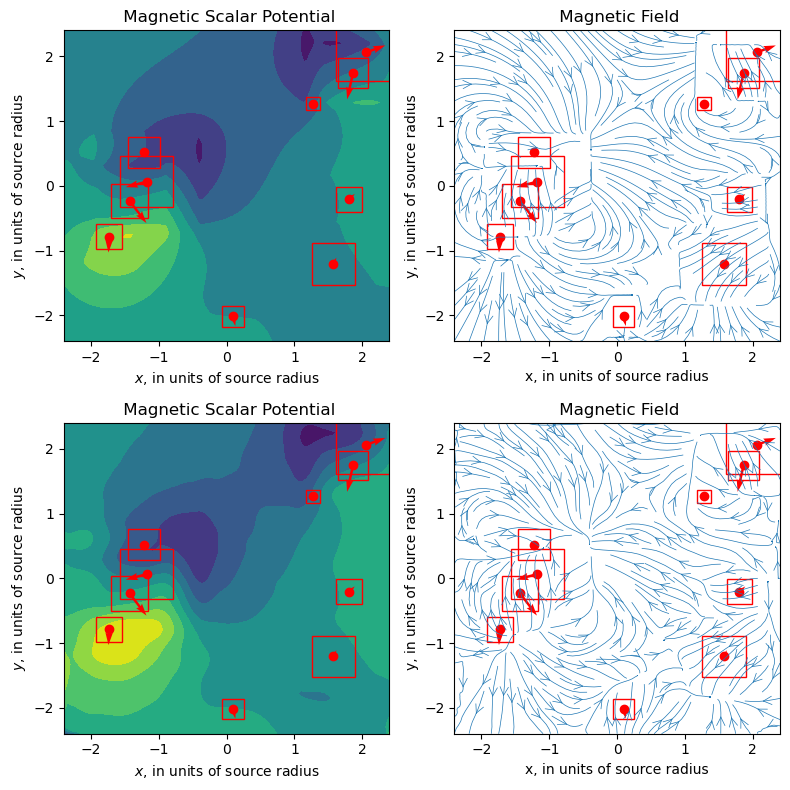

In [3]:
plots(val, idx=0, model=model)

Number of sources: 116


Potential Acc.: 5.76259708404541, Field Acc.: 28.708980560302734


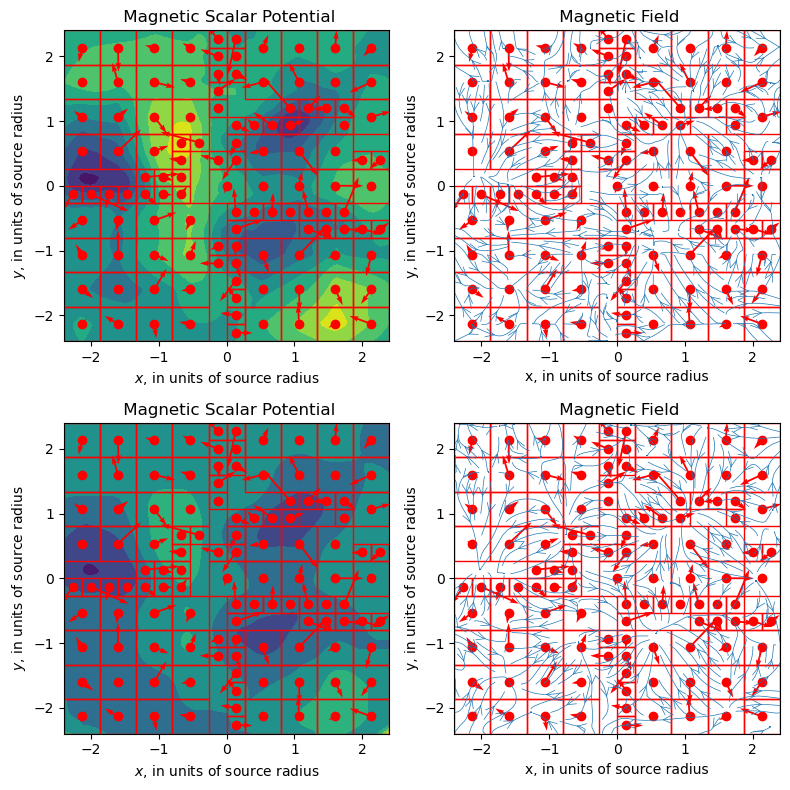

Number of sources: 97
Potential Acc.: 7.66892671585083, Field Acc.: 25.96102523803711


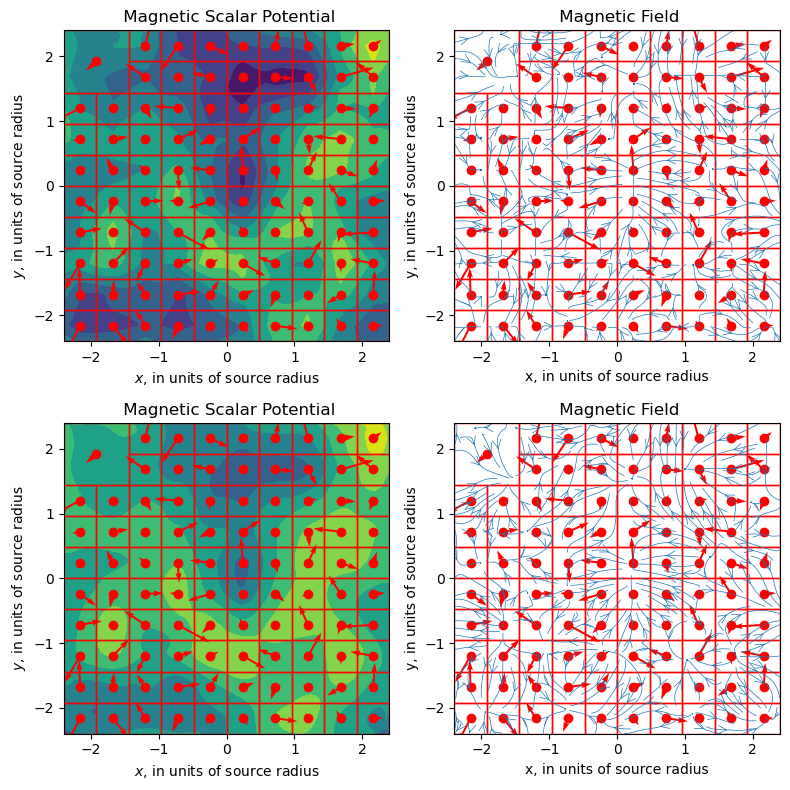

Number of sources: 112
Potential Acc.: 26.762489318847656, Field Acc.: 68.72306060791016


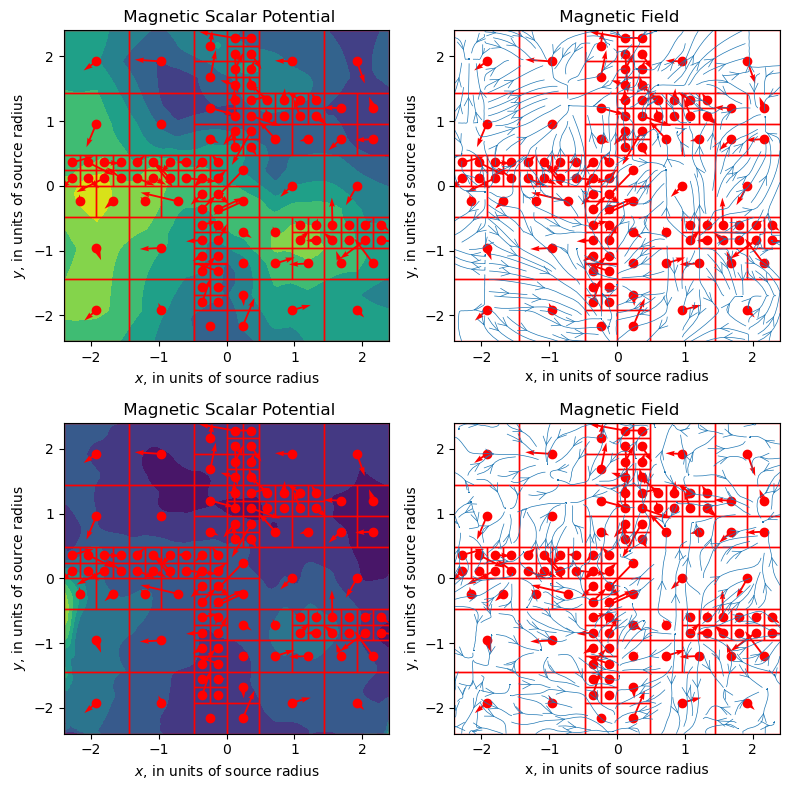

Number of sources: 73
Potential Acc.: 3.5474491119384766, Field Acc.: 24.013879776000977


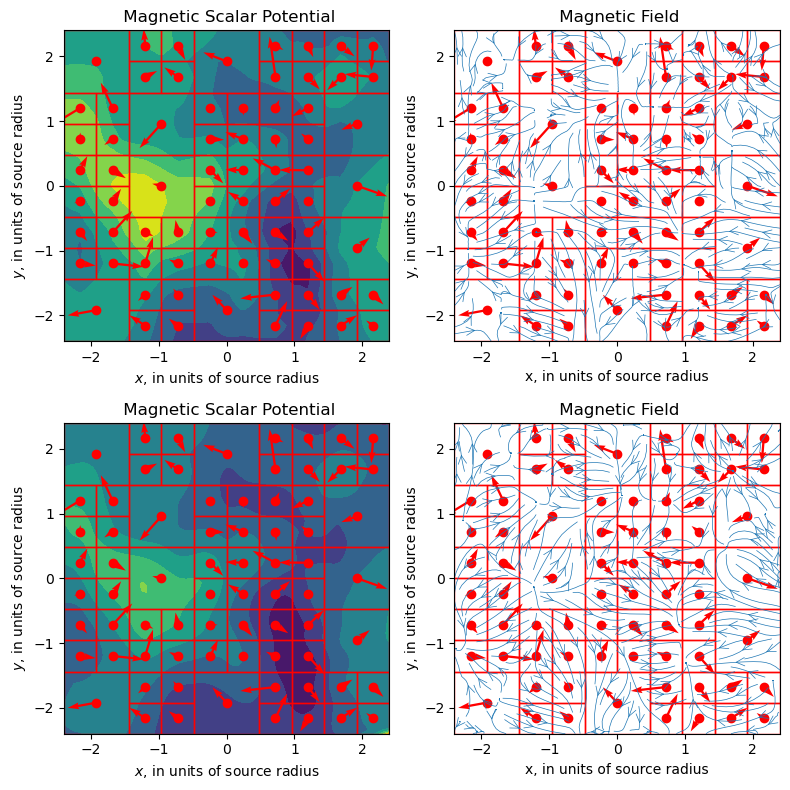

Number of sources: 49
Potential Acc.: 7.703721523284912, Field Acc.: 29.332324981689453


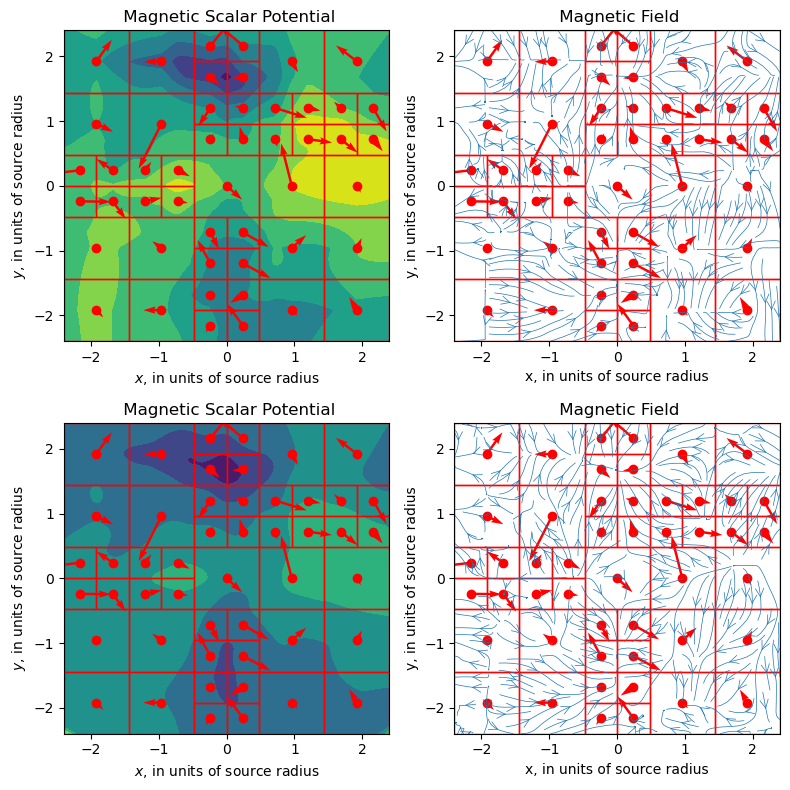

Number of sources: 201
Potential Acc.: 20.75821304321289, Field Acc.: 47.929962158203125


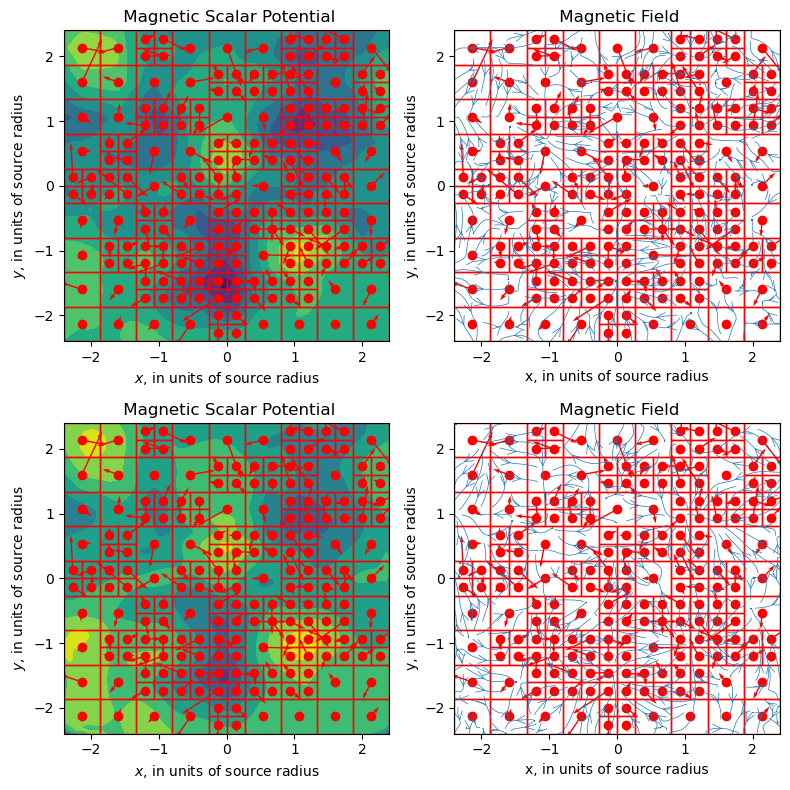

Number of sources: 142
Potential Acc.: 39.807647705078125, Field Acc.: 84.54440307617188


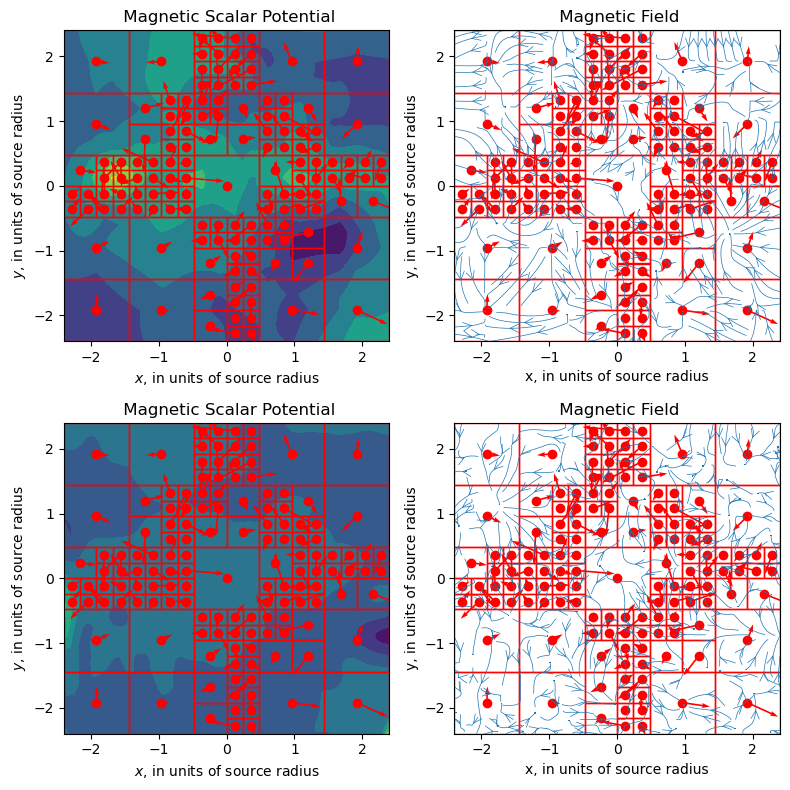

Number of sources: 67
Potential Acc.: 4.986133575439453, Field Acc.: 22.901348114013672


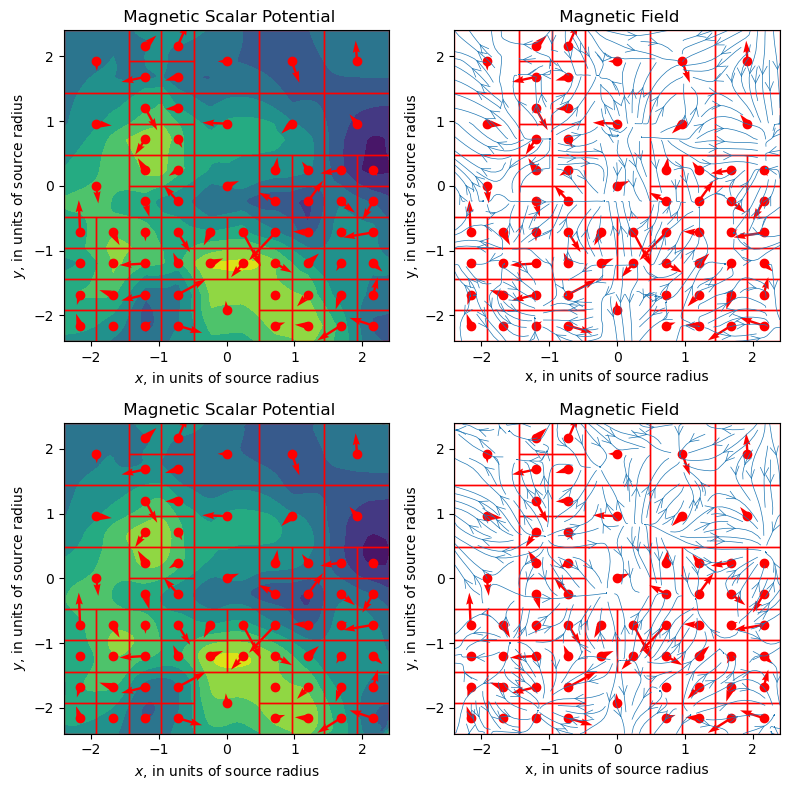

Number of sources: 52
Potential Acc.: 4.859865665435791, Field Acc.: 30.963375091552734


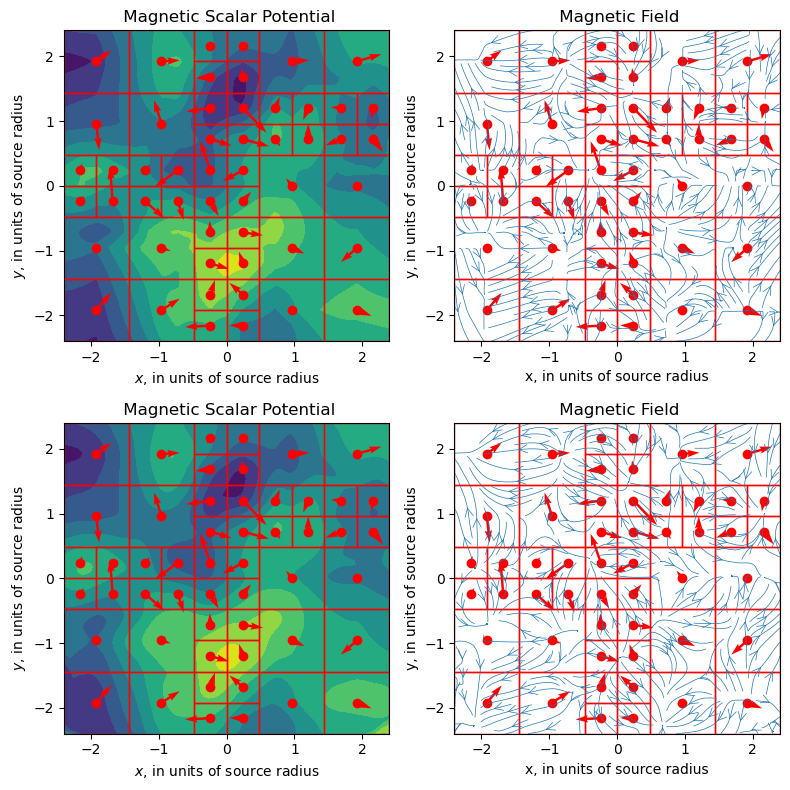

Number of sources: 78
Potential Acc.: 5.051022052764893, Field Acc.: 27.20885467529297


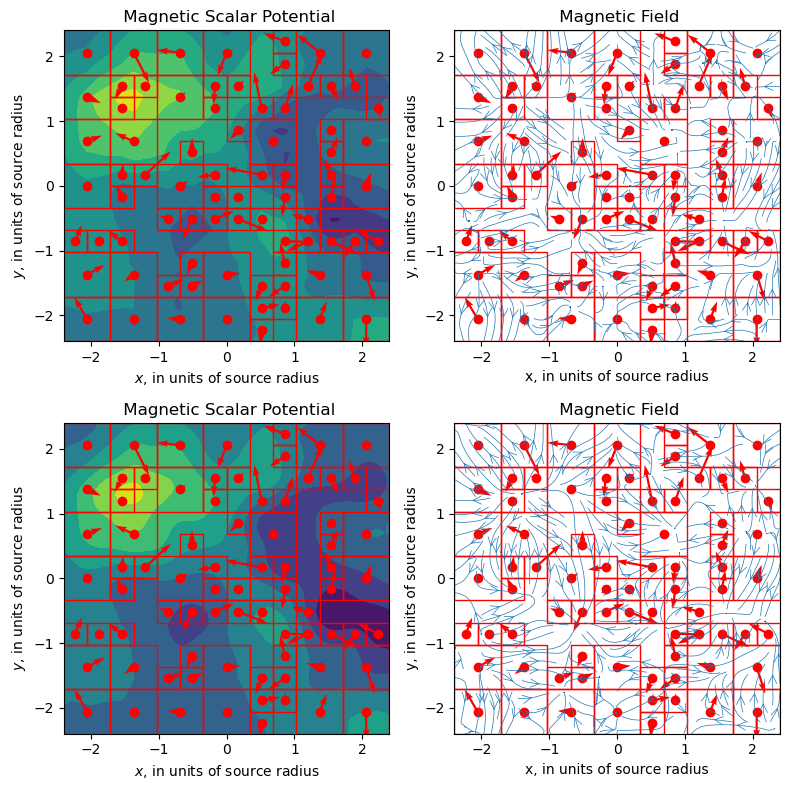

In [4]:
# Shape from Rasmus with minimum size of 0.25
from hypermagnetics.sources import configure, read_db
from hypermagnetics import plots

for file_idx in range(10):
    test = read_db(f"squares_1_{file_idx}_enlarged.h5", read_grid=True)
    print("Number of sources: " + str(test["sources"][:].shape[1]))
    print(f"Potential Acc.: {accuracy(model, test)}, Field Acc.: {accuracy_field(model, test)}")
    plots(test, idx=0, model=model)

In [7]:
from hypermagnetics.sources import configure, read_db
test_idx = 0
test = read_db(f"squares_1_{test_idx}.h5", read_grid=True)

In [8]:
import jax
import jax.numpy as jnp

mr = test["sources"][0 :1]
m, r0, size = jnp.split(mr, 3, axis=-1)
grid = test["grid"]

res = int(jnp.sqrt(len(grid)))
N = len(mr)
field_model = jax.vmap(model.field, in_axes=(0, None))(mr, test["grid"])

In [9]:
from hypermagnetics.sources import _field_mt

field_mt, _ = _field_mt(test["sources"], test["grid"], "prism")

In [10]:
sources, r, target = test["sources"], test["r"], test["field_grid"]
diff_mt = target[..., :2] - field_mt[..., :2] * jnp.pi**2
diff_model = target[..., :2] - field_model[..., :2]

for diff in [diff_mt, diff_model]:
    acc = jnp.linalg.norm(diff, axis=-1) / jnp.linalg.norm(target[..., :2], axis=-1) * 100
    # acc = replace_inf_nan(acc)
    print(jnp.median(acc))

0.00021195042
52.578705
